In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [32]:
df = pd.read_csv('data/House_Rent_Dataset.csv')
print("shape : ",df.shape)
print()
print(df.info())
print()
print(df.describe())
print()
print(df.head())
print("\n Missing values: ")
print(df.isnull().sum())
df = df.drop(['Posted On', 'Point of Contact'], axis = 'columns')


shape :  (4746, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB
None

               BHK          Rent         Size     Bathroom
count  4746.000000  4.746000e+03  4746.000000  4746.000000
mean      2.083860  3.499345e+04   967

## Univariate Analysis

In [33]:
df.groupby('Area Type')['Area Type'].agg('count')
df.drop(df.index[df['Area Type'] == 'Built Area'], inplace = True)
df.groupby('Area Type')['Area Type'].agg('count')
df.groupby('City')['City'].agg('count')
df.groupby('Furnishing Status')['Furnishing Status'].agg('count')
df.groupby('Tenant Preferred')['Tenant Preferred'].agg('count')
df.groupby('Floor')['Floor'].agg('count')
df.groupby('Area Locality')['Area Locality'].agg('count')
df = df.drop(['Floor'], axis='columns')
df.head()


,BHK,Rent,Size,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1


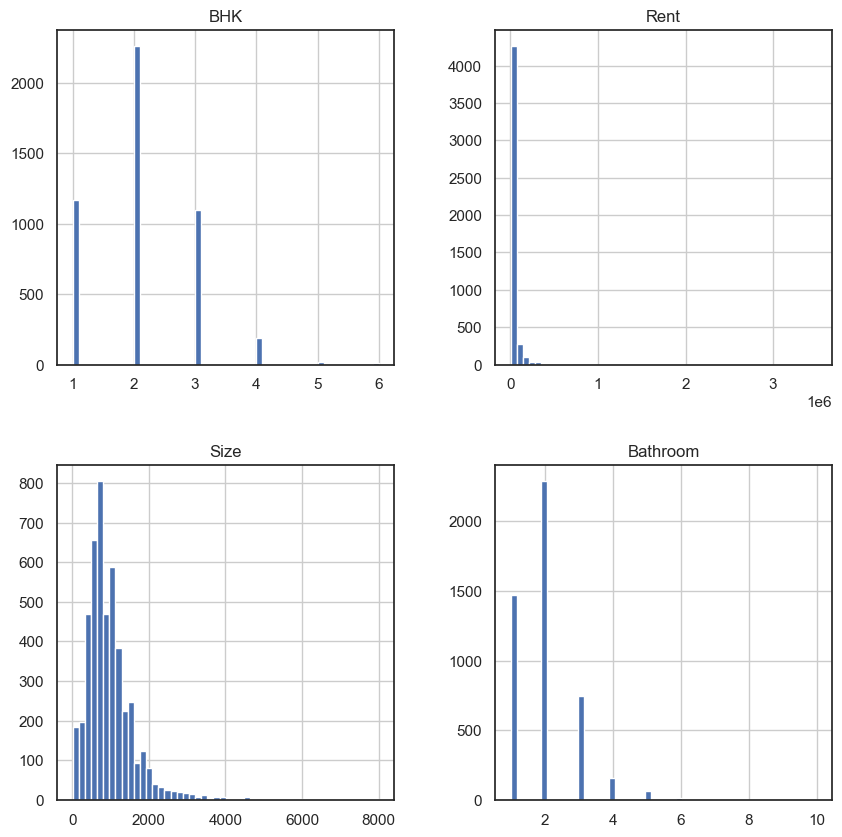

In [34]:
# Histogram of all numeric columns
df.hist(bins=50, figsize=(10, 10))
plt.ticklabel_format(useOffset=False, style='plain')
plt.show()

In [35]:
df.Rent.describe().apply(lambda x: format(x, 'f'))

count       4744.000000
mean       35003.777403
std        78121.204493
min         1200.000000
25%        10000.000000
50%        16000.000000
75%        33000.000000
max      3500000.000000
Name: Rent, dtype: object

## Multivariate Analysis

In [36]:
# Add new feature: price per sqft
df['Price_per_sqft'] = df['Rent'] * 1000 / df['Size']
df.head()

# Detect size per BHK outliers
# 300 sqft/BHK is the threshold — below that is unusual
df[(df.Size / df.BHK) < 300].head()
df.shape
df1 = df[~(df.Size / df.BHK < 300)]
df1.shape
df1.Price_per_sqft.describe().apply(lambda x: format(x, 'f'))

count       4196.000000
mean       32827.385605
std        41300.048982
min          571.428571
25%        13000.000000
50%        18511.595708
75%        34896.788991
max      1400000.000000
Name: Price_per_sqft, dtype: object

# 571 per sqft is too low and 1400000 per sqft is too high — need to remove these outliers

In [37]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('City'):
        m = np.mean(subdf.Price_per_sqft)
        st = np.std(subdf.Price_per_sqft)
        reduced_df = subdf[
            (subdf.Price_per_sqft > (m - st)) & 
            (subdf.Price_per_sqft <= (m + st))
        ]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df2 = remove_pps_outliers(df1)
df2.shape


(3699, 10)

In [11]:
# 2 BHK with 4 bathrooms is unusual — threshold: bathrooms must not exceed BHK + 2
df2[df2.Bathroom > df2.BHK + 2]

,BHK,Rent,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Price_per_sqft
860,3,20000,1700,Carpet Area,Chennai,Furnished,Bachelors/Family,6,11764.705882
1904,4,150000,4000,Carpet Area,Delhi,Semi-Furnished,Bachelors,7,37500.000000
3328,1,40000,680,Super Area,Mumbai,Furnished,Bachelors/Family,4,58823.529412


Localities: 51 unique kept


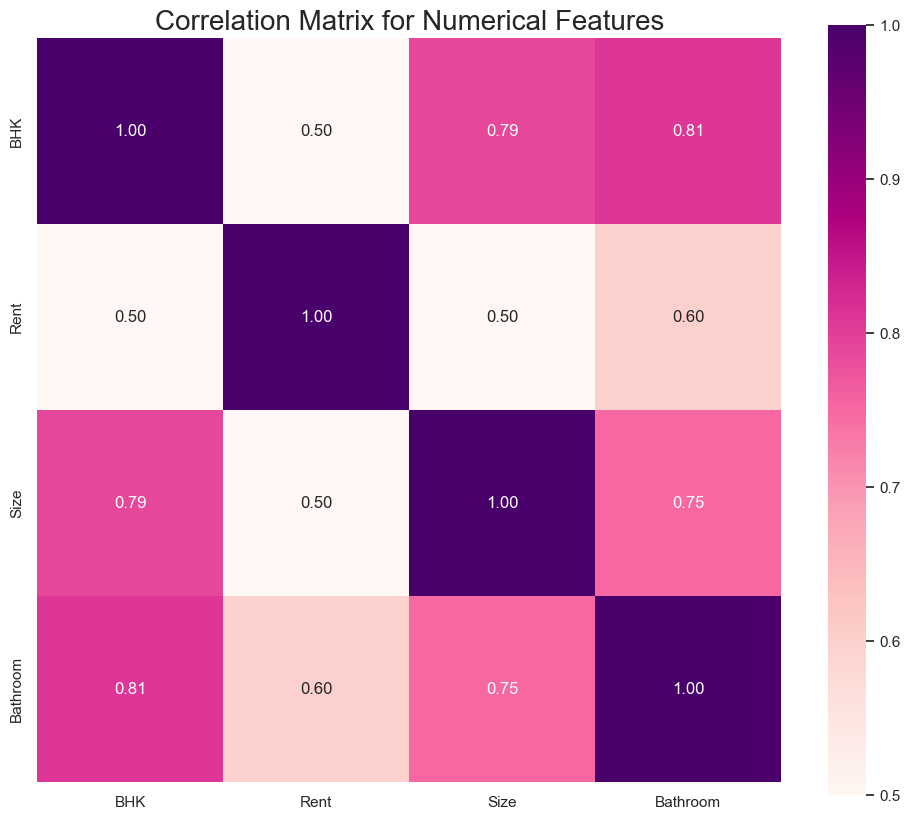

In [38]:
# Remove bathroom outliers
df2 = df2[~(df2.Bathroom > df2.BHK + 2)]

# Drop unnecessary column
df3 = df2.drop(['Price_per_sqft'], axis='columns')

top_localities = df3['Area Locality'].value_counts().head(50).index
df3['Locality_clean'] = df3['Area Locality'].apply(
    lambda x: x if x in top_localities else 'Other'
)
df3 = df3.drop(['Area Locality'], axis='columns')
print(f'Localities: {df3["Locality_clean"].nunique()} unique kept')

# Select only numeric columns
df3_numeric = df3.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = df3_numeric.corr().round(2)
sns.set_theme(style="white")
# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdPu',  
    fmt='.2f',
    square=True
)

plt.title("Correlation Matrix for Numerical Features", size=20)
plt.show()

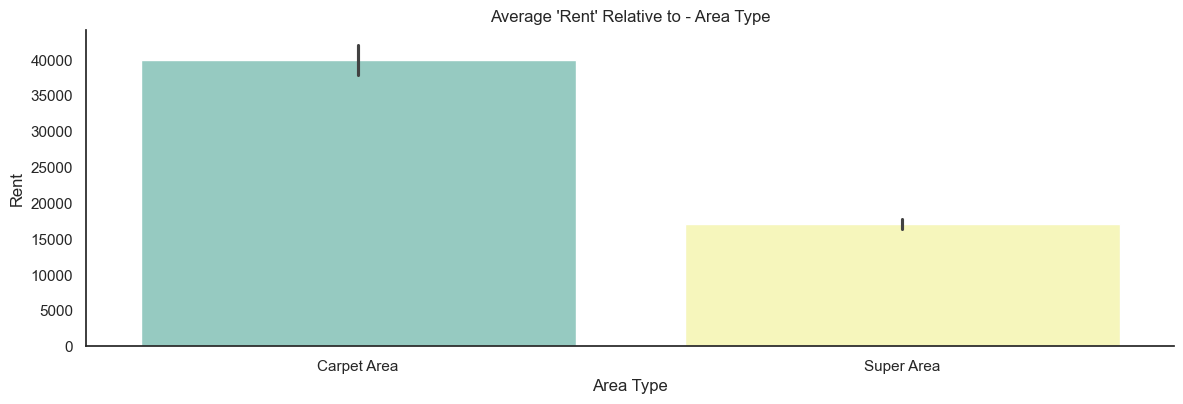

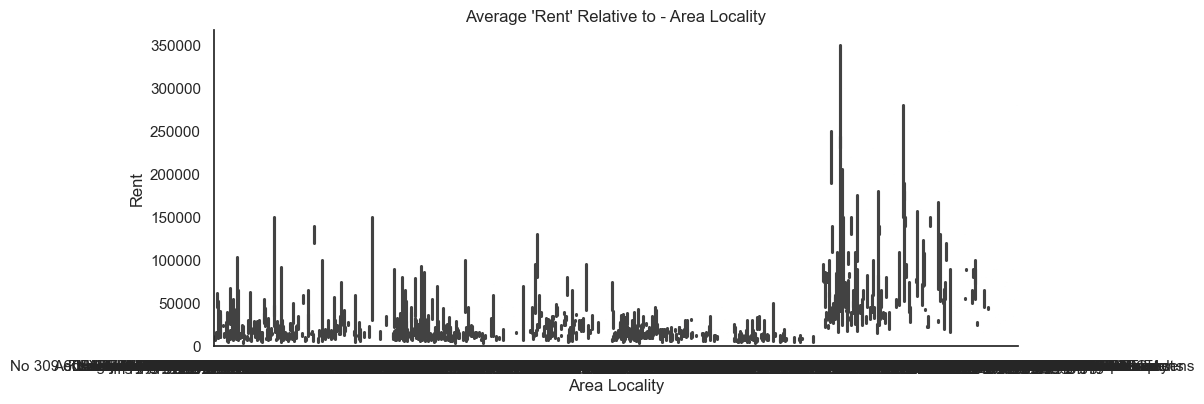

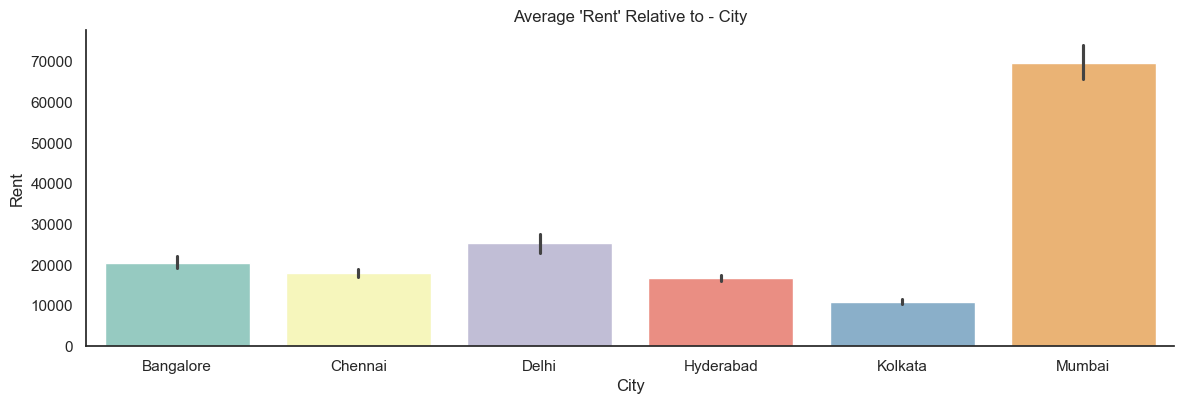

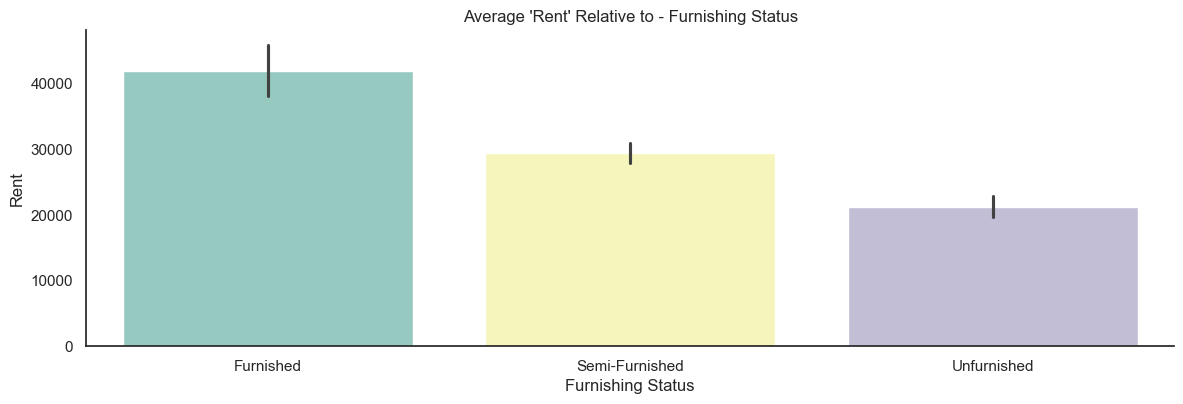

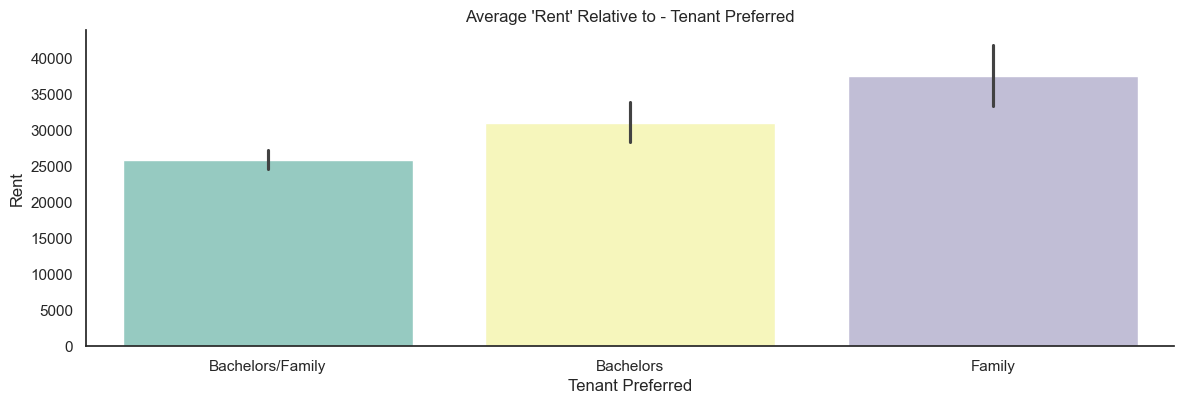

In [39]:
# Correlation between categorical features and target (Rent)
cat_features = df2.select_dtypes(include='object').columns.to_list()

for col in cat_features:
    sns.catplot(x=col, y="Rent", kind="bar", dodge=False,
                height=4, aspect=3, data=df2, palette="Set3")
    plt.title("Average 'Rent' Relative to - {}".format(col))
    plt.show()

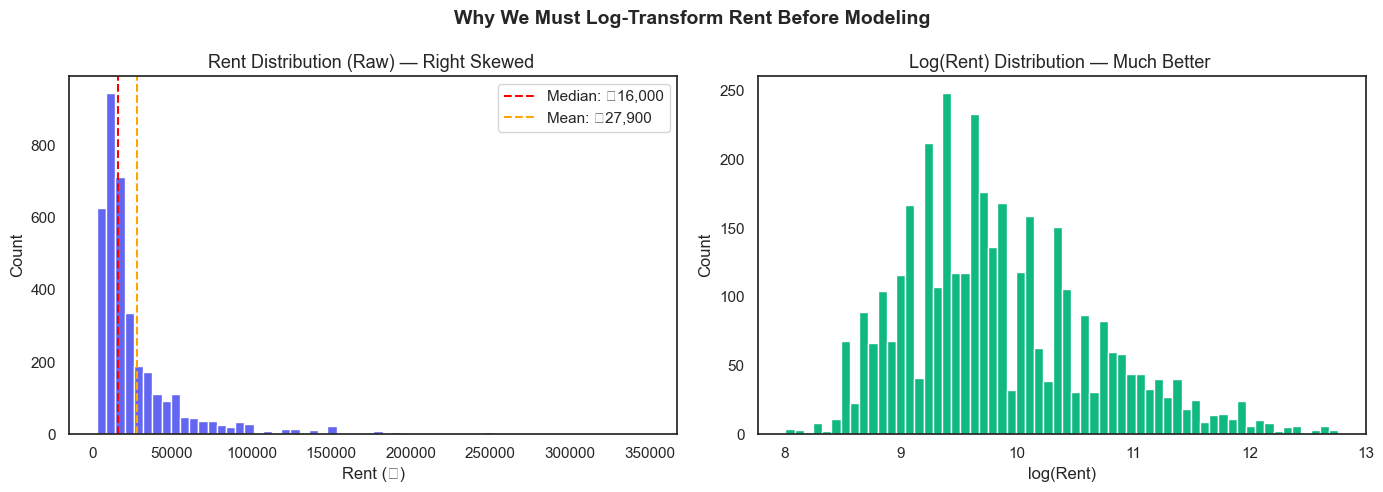

Skewness (Raw Rent):      4.04  ← high skew is bad for models
Skewness (Log Rent):      0.73  ← close to 0 is ideal


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Rent — skewed
axes[0].hist(df3['Rent'], bins=60, color='#6366f1', edgecolor='white')
axes[0].set_title('Rent Distribution (Raw) — Right Skewed ', fontsize=13)
axes[0].set_xlabel('Rent (₹)')
axes[0].set_ylabel('Count')
axes[0].axvline(df3['Rent'].median(), color='red', linestyle='--', label=f'Median: ₹{df3["Rent"].median():,.0f}')
axes[0].axvline(df3['Rent'].mean(), color='orange', linestyle='--', label=f'Mean: ₹{df3["Rent"].mean():,.0f}')
axes[0].legend()

# Log Rent — more normal
import numpy as np
axes[1].hist(np.log1p(df3['Rent']), bins=60, color='#10b981', edgecolor='white')
axes[1].set_title('Log(Rent) Distribution — Much Better ', fontsize=13)
axes[1].set_xlabel('log(Rent)')
axes[1].set_ylabel('Count')

plt.suptitle('Why We Must Log-Transform Rent Before Modeling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness (Raw Rent):      {df3["Rent"].skew():.2f}  ← high skew is bad for models')
print(f'Skewness (Log Rent):      {np.log1p(df3["Rent"]).skew():.2f}  ← close to 0 is ideal')

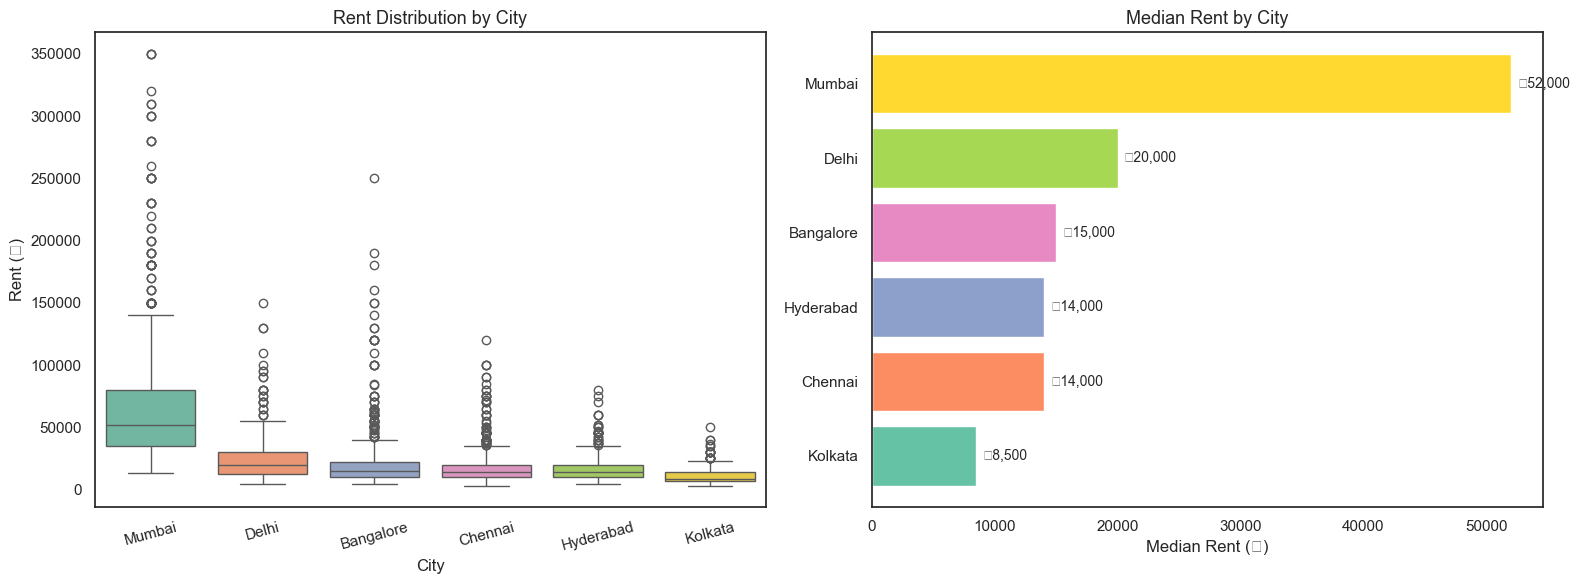

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# City-wise rent boxplot
city_order = df3.groupby('City')['Rent'].median().sort_values(ascending=False).index
sns.boxplot(data=df3, x='City', y='Rent', order=city_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('Rent Distribution by City', fontsize=13)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Rent (₹)')
axes[0].tick_params(axis='x', rotation=15)

# City-wise median rent barplot
median_rent = df3.groupby('City')['Rent'].median().sort_values(ascending=True)
bars = axes[1].barh(median_rent.index, median_rent.values,
                     color=sns.color_palette('Set2', len(median_rent)))
axes[1].set_title('Median Rent by City', fontsize=13)
axes[1].set_xlabel('Median Rent (₹)')
for bar, val in zip(bars, median_rent.values):
    axes[1].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'₹{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

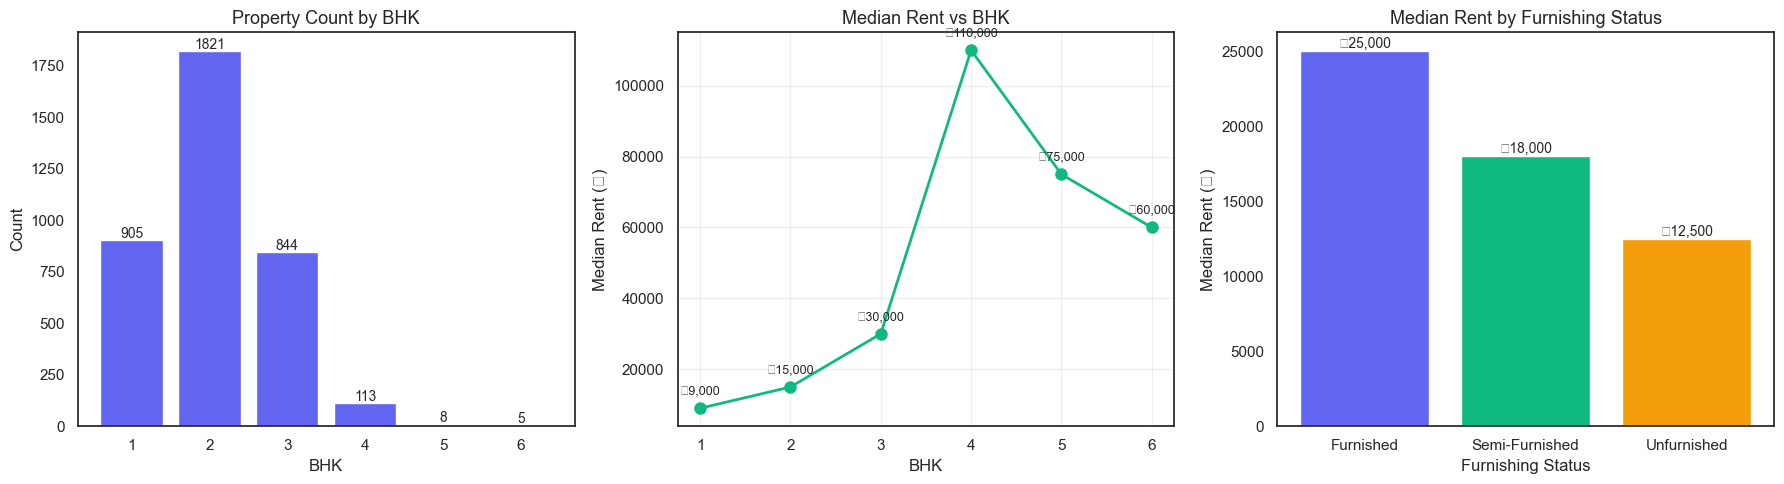

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BHK count distribution
bhk_counts = df3['BHK'].value_counts().sort_index()
axes[0].bar(bhk_counts.index.astype(str), bhk_counts.values,
            color='#6366f1', edgecolor='white')
axes[0].set_title('Property Count by BHK', fontsize=13)
axes[0].set_xlabel('BHK')
axes[0].set_ylabel('Count')
for i, v in enumerate(bhk_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

# Median Rent by BHK
bhk_rent = df3.groupby('BHK')['Rent'].median()
axes[1].plot(bhk_rent.index, bhk_rent.values, 'o-',
             color='#10b981', linewidth=2, markersize=8)
axes[1].set_title('Median Rent vs BHK', fontsize=13)
axes[1].set_xlabel('BHK')
axes[1].set_ylabel('Median Rent (₹)')
axes[1].grid(True, alpha=0.3)
for x, y in zip(bhk_rent.index, bhk_rent.values):
    axes[1].annotate(f'₹{y:,.0f}', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# Furnishing status
furnish_rent = df3.groupby('Furnishing Status')['Rent'].median().sort_values(ascending=False)
colors = ['#6366f1', '#10b981', '#f59e0b']
axes[2].bar(furnish_rent.index, furnish_rent.values, color=colors, edgecolor='white')
axes[2].set_title('Median Rent by Furnishing Status', fontsize=13)
axes[2].set_xlabel('Furnishing Status')
axes[2].set_ylabel('Median Rent (₹)')
for i, v in enumerate(furnish_rent.values):
    axes[2].text(i, v + 200, f'₹{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

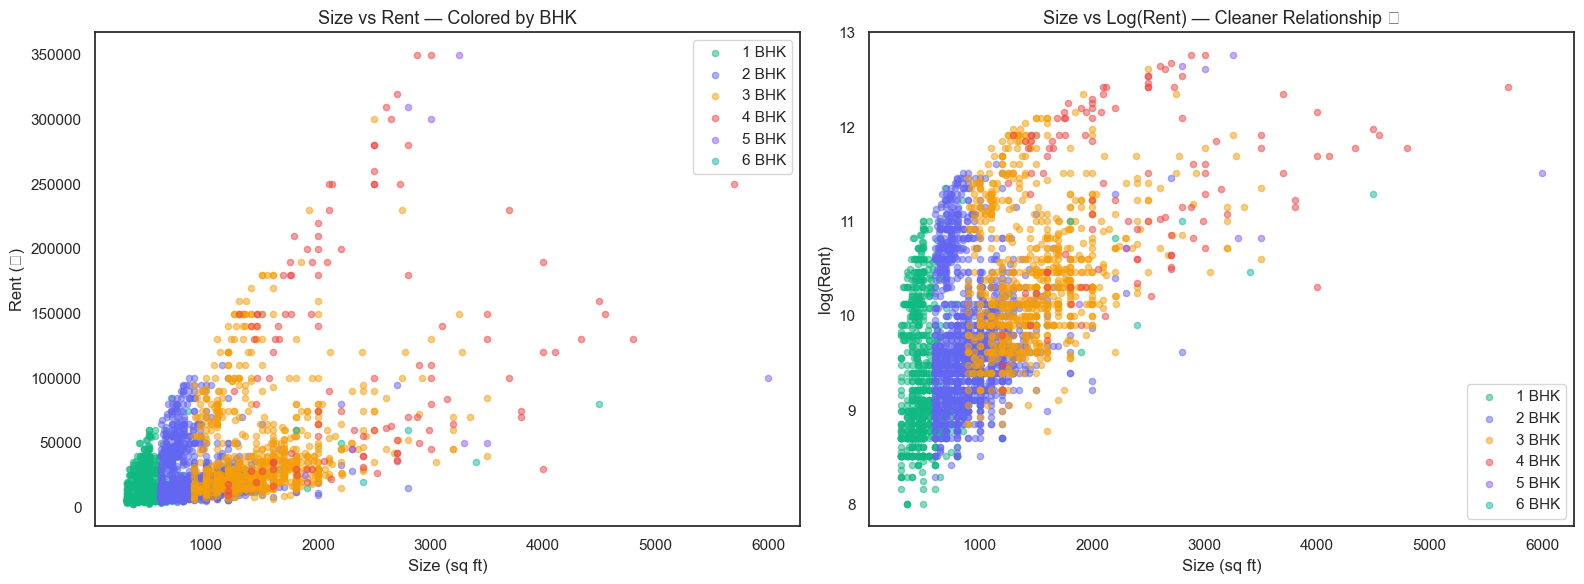

Correlation: Size vs Rent        = 0.498
Correlation: Size vs log(Rent)   = 0.531


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Size vs Rent — colored by BHK
bhk_palette = {1:'#10b981', 2:'#6366f1', 3:'#f59e0b', 4:'#ef4444', 5:'#8b5cf6', 6:'#14b8a6'}
for bhk, group in df3.groupby('BHK'):
    axes[0].scatter(group['Size'], group['Rent'],
                    c=bhk_palette.get(bhk, 'gray'),
                    label=f'{bhk} BHK', alpha=0.5, s=20)
axes[0].set_title('Size vs Rent — Colored by BHK', fontsize=13)
axes[0].set_xlabel('Size (sq ft)')
axes[0].set_ylabel('Rent (₹)')
axes[0].legend()

# Size vs Log(Rent) — cleaner linear relationship
for bhk, group in df3.groupby('BHK'):
    axes[1].scatter(group['Size'], np.log1p(group['Rent']),
                    c=bhk_palette.get(bhk, 'gray'),
                    label=f'{bhk} BHK', alpha=0.5, s=20)
axes[1].set_title('Size vs Log(Rent) — Cleaner Relationship ', fontsize=13)
axes[1].set_xlabel('Size (sq ft)')
axes[1].set_ylabel('log(Rent)')
axes[1].legend()

plt.tight_layout()
plt.show()

corr_raw = df3['Size'].corr(df3['Rent'])
corr_log = df3['Size'].corr(np.log1p(df3['Rent']))
print(f'Correlation: Size vs Rent        = {corr_raw:.3f}')
print(f'Correlation: Size vs log(Rent)   = {corr_log:.3f}')

#  Data Preparation — Continue From Here

## Step 1: Log-Transform Target + Feature Engineering

In [49]:
df_model = df3.copy()

# 1. Log-transform target
df_model['Log_Rent'] = np.log1p(df_model['Rent'])

# 2. Engineered features
df_model['Size_per_BHK']       = df_model['Size'] / df_model['BHK']
df_model['Bath_per_BHK']       = df_model['Bathroom'] / df_model['BHK']
df_model['Size_x_BHK']         = df_model['Size'] * df_model['BHK']

# 3. Target encoding — city/furnishing median rent (very powerful feature!)
city_median    = df_model.groupby('City')['Rent'].median()
furnish_median = df_model.groupby('Furnishing Status')['Rent'].median()
df_model['City_Median_Rent']    = df_model['City'].map(city_median)
df_model['Furnish_Median_Rent'] = df_model['Furnishing Status'].map(furnish_median)

# 4. One-hot encode categorical columns (on df_model, NOT df3!)
cat_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Locality_clean']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print('Shape after encoding:', df_encoded.shape)
print('All features:', df_encoded.columns.tolist())

Shape after encoding: (3696, 70)
All features: ['BHK', 'Rent', 'Size', 'Bathroom', 'Log_Rent', 'Size_per_BHK', 'Bath_per_BHK', 'Size_x_BHK', 'City_Median_Rent', 'Furnish_Median_Rent', 'Area Type_Super Area', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'Furnishing Status_Semi-Furnished', 'Furnishing Status_Unfurnished', 'Tenant Preferred_Bachelors/Family', 'Tenant Preferred_Family', 'Locality_clean_Andheri West', 'Locality_clean_Attapur', 'Locality_clean_Bandlaguda Jagir', 'Locality_clean_Bandra West', 'Locality_clean_Banjara Hills, NH 9', 'Locality_clean_Behala', 'Locality_clean_Chembur', 'Locality_clean_Chhattarpur', 'Locality_clean_Chhattarpur Enclave', 'Locality_clean_Chromepet, GST Road', 'Locality_clean_Electronic City', 'Locality_clean_Electronic City Phase 2, Electronic City', 'Locality_clean_Gachibowli', 'Locality_clean_Garia', 'Locality_clean_Goregaon West', 'Locality_clean_Hebbal', 'Locality_clean_Himayath Nagar, NH 7', 'Locality_clean_Iyyap

## Step 3: Train-Test Split (80/20)

In [50]:
X = df_encoded.drop(columns=['Rent', 'Log_Rent'])
y = df_encoded['Log_Rent']

# 80/20 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape}  ({len(X_test)/len(X)*100:.0f}%)')

Train: (2956, 68)  (80%)
Test:  (740, 68)  (20%)


## Step 4: Normalize Numeric Features

In [51]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'BHK', 'Size', 'Bathroom',
    'Size_per_BHK', 'Bath_per_BHK', 'Size_x_BHK',
    'City_Median_Rent', 'Furnish_Median_Rent'
]

scaler = StandardScaler()
# IMPORTANT: fit only on train data!
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features]  = scaler.transform(X_test[numerical_features])

print('Scaling done!')
print(X_train[numerical_features].describe().round(2))


Scaling done!
           BHK     Size  Bathroom  Size_per_BHK  Bath_per_BHK  Size_x_BHK  \
count  2956.00  2956.00   2956.00       2956.00       2956.00     2956.00   
mean      0.00     0.00      0.00         -0.00          0.00       -0.00   
std       1.00     1.00      1.00          1.00          1.00        1.00   
min      -1.31    -1.30     -1.16         -1.29         -2.71       -0.91   
25%      -0.38    -0.65     -1.16         -0.64          0.07       -0.52   
50%      -0.07    -0.18      0.05         -0.21          0.07       -0.26   
75%       1.18     0.38      0.05          0.46          0.07        0.26   
max       4.91     9.28      6.11         11.96          7.48       11.97   

       City_Median_Rent  Furnish_Median_Rent  
count           2956.00              2956.00  
mean              -0.00                 0.00  
std                1.00                 1.00  
min               -0.86                -1.06  
25%               -0.49                -1.06  
50%       

---
#  Modeling — Train 3 Models

In [52]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2     = r2_score(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    rent_mae = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred))
    print(f'\n{"-"*48}')
    print(f'  {name}')
    print(f'{"-"*48}')
    print(f'  R² Score : {r2:.4f}')
    print(f'  Log RMSE : {rmse:.4f}')
    print(f'  MAE (₹)  : ₹{rent_mae:,.0f}  ← avg error per prediction')
    return model

# 1. Linear Regression — simple baseline
lr = evaluate_model('Linear Regression (Baseline)',
    LinearRegression(), X_train, X_test, y_train, y_test)

# 2. Random Forest — stable, low overfitting
rf = evaluate_model('Random Forest',
    RandomForestRegressor(n_estimators=300, max_depth=20,
                          min_samples_leaf=3, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test)

# 3. Gradient Boosting — best accuracy
gb = evaluate_model('Gradient Boosting (Best)',
    GradientBoostingRegressor(n_estimators=400, learning_rate=0.04,
                              max_depth=5, min_samples_leaf=5,
                              subsample=0.8, random_state=42),
    X_train, X_test, y_train, y_test)


------------------------------------------------
  Linear Regression (Baseline)
------------------------------------------------
  R² Score : 0.8573
  Log RMSE : 0.3023
  MAE (₹)  : ₹6,759  ← avg error per prediction

------------------------------------------------
  Random Forest
------------------------------------------------
  R² Score : 0.8495
  Log RMSE : 0.3104
  MAE (₹)  : ₹6,494  ← avg error per prediction

------------------------------------------------
  Gradient Boosting (Best)
------------------------------------------------
  R² Score : 0.8598
  Log RMSE : 0.2995
  MAE (₹)  : ₹6,361  ← avg error per prediction


## Feature Importance (Which Features Matter Most?)

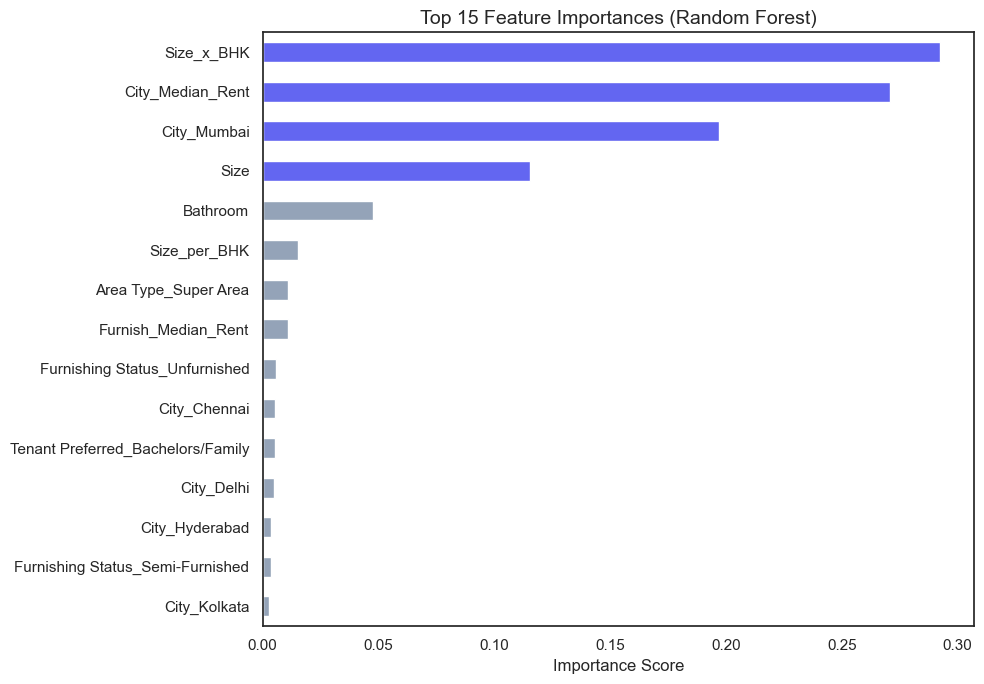

Top 5 features:
  Size_x_BHK                          0.2925
  City_Median_Rent                    0.2710
  City_Mumbai                         0.1971
  Size                                0.1155
  Bathroom                            0.0474


In [53]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
colors = ['#6366f1' if v > 0.05 else '#94a3b8' for v in top15.values]
top15.plot(kind='barh', color=colors)
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, score in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<35} {score:.4f}')

# Evaluation — Actual vs Predicted + Residuals

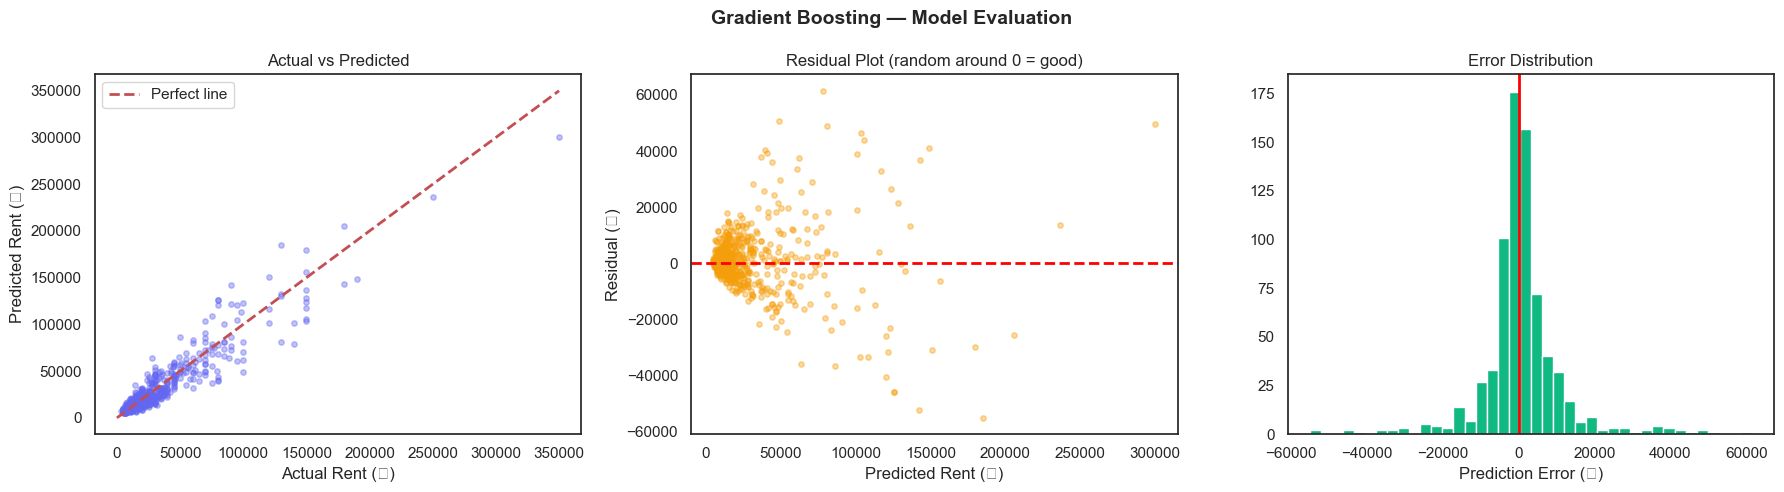

  FINAL PERFORMANCE (Gradient Boosting)
  R² Score : 0.8838
  MAE      : ₹6,361
  RMSE     : ₹10,821


In [54]:
best_model = gb  # Gradient Boosting

y_pred_log  = best_model.predict(X_test)
y_pred_rent = np.expm1(y_pred_log)
y_test_rent = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_rent, y_pred_rent, alpha=0.4, color='#6366f1', s=15)
max_val = max(y_test_rent.max(), y_pred_rent.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect line')
axes[0].set_xlabel('Actual Rent (₹)')
axes[0].set_ylabel('Predicted Rent (₹)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# 2. Residuals
residuals = y_test_rent - y_pred_rent
axes[1].scatter(y_pred_rent, residuals, alpha=0.4, color='#f59e0b', s=15)
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Rent (₹)')
axes[1].set_ylabel('Residual (₹)')
axes[1].set_title('Residual Plot (random around 0 = good)')

# 3. Error distribution
axes[2].hist(residuals, bins=40, color='#10b981', edgecolor='white')
axes[2].axvline(0, color='red', lw=2)
axes[2].set_xlabel('Prediction Error (₹)')
axes[2].set_title('Error Distribution')

plt.suptitle('Gradient Boosting — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('='*48)
print('  FINAL PERFORMANCE (Gradient Boosting)')
print('='*48)
print(f'  R² Score : {r2_score(y_test_rent, y_pred_rent):.4f}')
print(f'  MAE      : ₹{mean_absolute_error(y_test_rent, y_pred_rent):,.0f}')
print(f'  RMSE     : ₹{np.sqrt(mean_squared_error(y_test_rent, y_pred_rent)):,.0f}')

## Sample Predictions — Compare All 3 Models

In [55]:
sample  = X_test.iloc[:8].copy()
actual  = np.expm1(y_test.iloc[:8])

results = pd.DataFrame({
    'Actual (₹)':     actual.values.astype(int),
    'Linear Reg (₹)': np.expm1(lr.predict(sample)).astype(int),
    'RandomForest (₹)': np.expm1(rf.predict(sample)).astype(int),
    'GradBoost (₹)':  np.expm1(gb.predict(sample)).astype(int),
})
results['RF Error (₹)'] = (results['RandomForest (₹)'] - results['Actual (₹)']).abs()
results['GB Error (₹)'] = (results['GradBoost (₹)']   - results['Actual (₹)']).abs()

print(results.to_string(index=False))

 Actual (₹)  Linear Reg (₹)  RandomForest (₹)  GradBoost (₹)  RF Error (₹)  GB Error (₹)
      12999           16113             14890          15582          1891          2583
      64999           37322             37284          39317         27715         25682
      16499           18178             14386          15129          2113          1370
      11999            8591              7510           7065          4489          4934
      14999           21982             17546          17937          2547          2938
      10999            8699             10241           8668           758          2331
      13999           18178             14386          15129           387          1130
      29999           25157             19795          21813         10204          8186


In [61]:
import joblib

joblib.dump(gb, 'house_rent_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Model saved as house_rent_model.pkl')
print('Scaler saved as scaler.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl') 
joblib.dump(numerical_features, 'num_feats.pkl') 

Model saved as house_rent_model.pkl
Scaler saved as scaler.pkl


['num_feats.pkl']

## Predict Rent for a New Property

In [66]:
# Load and predict
model           = joblib.load('house_rent_model.pkl')
sc              = joblib.load('scaler.pkl')
model_columns   = joblib.load('model_columns.pkl')
num_feats_saved = joblib.load('num_feats.pkl')
# Build input — must match the exact columns from X_train
# Change these values to predict different properties
city_medians    = df3.groupby('City')['Rent'].median().to_dict()
furnish_medians = df3.groupby('Furnishing Status')['Rent'].median().to_dict()

def predict_rent(bhk, size, bathroom, city, furnishing,
                 locality='Other', area_type='Super Area',
                 tenant='Bachelors/Family'):
    inp = {
        'BHK': bhk, 'Size': size, 'Bathroom': bathroom,
        'Size_per_BHK': size / bhk,
        'Bath_per_BHK': bathroom / bhk,
        'Size_x_BHK':   size * bhk,
        'City_Median_Rent':    city_medians.get(city, 20000),
        'Furnish_Median_Rent': furnish_medians.get(furnishing, 15000),
    }
    input_df = pd.DataFrame([inp])
    input_df = input_df.reindex(columns=model_columns, fill_value=0)
    input_df[num_feats_saved] = sc.transform(input_df[num_feats_saved])
    return round(np.expm1(model.predict(input_df)[0]))

examples = [
    dict(bhk=2, size=1000, bathroom=2, city='Mumbai',    furnishing='Semi-Furnished'),
    dict(bhk=3, size=1500, bathroom=3, city='Bangalore', furnishing='Furnished'),
    dict(bhk=1, size=500,  bathroom=1, city='Kolkata',   furnishing='Unfurnished'),
]
for e in examples:
    rent = predict_rent(**e)
    print(f"{e['bhk']}BHK {e['size']}sqft {e['city']} ({e['furnishing']}) → ₹{rent:,}/month")

2BHK 1000sqft Mumbai (Semi-Furnished) → ₹37,990/month
3BHK 1500sqft Bangalore (Furnished) → ₹42,270/month
1BHK 500sqft Kolkata (Unfurnished) → ₹7,256/month
